In [2]:
from train import get_dataloader, TrainModel
import torch 
from torch import nn as nn 
import pytorch_lightning as pl 
from einops import rearrange
from matplotlib import pyplot as plt 
from torch.nn import functional as F 

## test for dice

In [10]:
mask_true = torch.randint(0, 5, size = (8,  128, 128))
n_classes = torch.unique(mask_true)
mask_true = F.one_hot(mask_true, n_classes.shape[0])


In [11]:
mask_true.shape 

torch.Size([8, 128, 128, 5])

In [2]:
model = TrainModel.load_from_checkpoint('/home/kathy/projects/project_guo/test/logs/logger_train/version_1/checkpoints/epoch=99-step=3100.ckpt')

In [3]:
train_loader, val_laoder = get_dataloader()

In [51]:
lis = []
for X, y in train_loader:
    X = rearrange(X, "b n c h w -> (b n) c h w")
    X = X.to(torch.device("cuda:3"))
    pred = model(X)
    res = pred.argmax(dim = 1)
    y = rearrange(y, "b n c h w -> (b n) c h w") 
    X = X.cpu()
    lis.append((res == y).sum() / (64 * 128 ** 2))

/home/kathy/anaconda3/envs/hkx/lib/python3.8/site-packages/einops/einops.py:190: UserWarning: __rfloordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  inferred_length: int = length // known_product


RuntimeError: CUDA out of memory. Tried to allocate 1024.00 MiB (GPU 3; 10.76 GiB total capacity; 9.02 GiB already allocated; 309.44 MiB free; 9.49 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [52]:
lis 

[]

In [5]:
X.shape 

torch.Size([16, 4, 1, 128, 128])

In [6]:
X = rearrange(X, "b n c h w -> (b n) c h w")

In [7]:
X = X.to(torch.device("cuda:3"))

In [8]:
pred = model(X)

/home/kathy/anaconda3/envs/hkx/lib/python3.8/site-packages/einops/einops.py:190: UserWarning: __rfloordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  inferred_length: int = length // known_product
/home/kathy/anaconda3/envs/hkx/lib/python3.8/site-packages/torch/nn/functional.py:3722: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


In [9]:
pred.shape 

torch.Size([64, 5, 128, 128])

In [10]:
res = pred.argmax(dim = 1)

In [11]:
res.shape 

torch.Size([64, 128, 128])

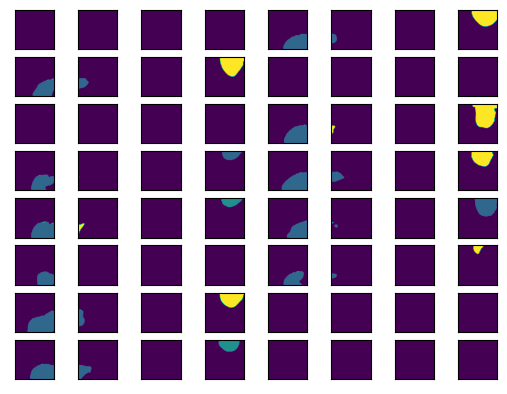

In [17]:
fig, axes = plt.subplots(8, 8)
for i in range(64):
    ax = axes.flatten()[i]
    ax.imshow(res.cpu().detach().numpy()[i])
    ax.set_xticks([])
    ax.set_yticks([])

In [20]:
y = rearrange(y, "b n c h w -> (b n) c h w") 

In [33]:
y = rearrange(y, "(b n) h w -> b n h w", n = 4) 

In [34]:
y.shape 

torch.Size([16, 4, 128, 128])

In [40]:
y.shape 

torch.Size([16, 4, 128, 128])

In [44]:
lt = y[0, 0, ...]
lr = y[0, 1, ...]
br = y[0, 2, ...]
bl = y[0, 3, ...]
bl.shape 

torch.Size([128, 128])

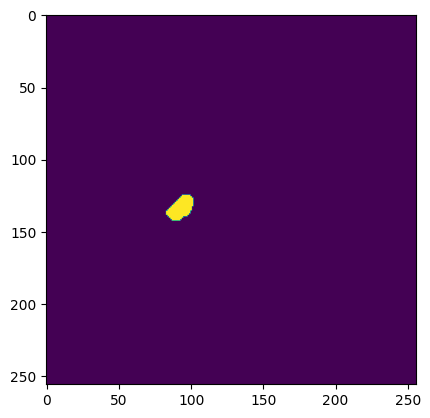

In [50]:
img = torch.cat((torch.cat((lt, lr), dim = 1), torch.cat((bl, br), dim = 1)), dim = 0) 
plt.imshow(img.detach().numpy())


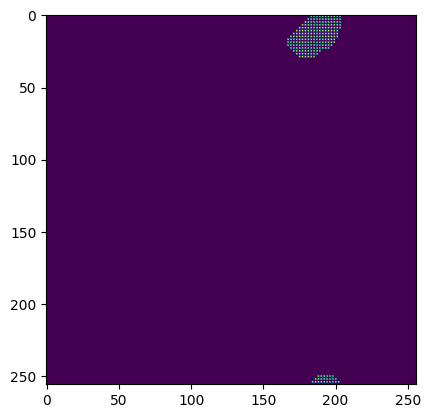

In [39]:
img = rearrange(y[0], "(n02 n01) h w -> (h n01) (w n02)", n01 = 2, n02 = 2 ) 
plt.imshow(img.detach().numpy())

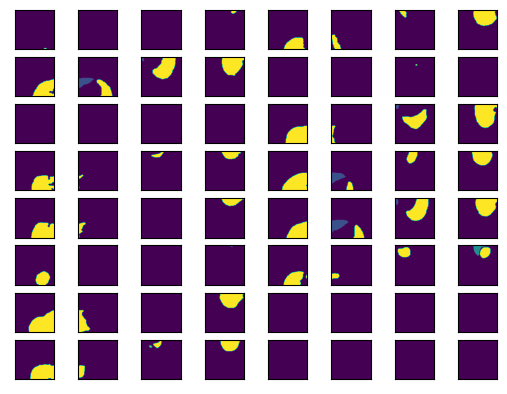

In [23]:
fig, axes = plt.subplots(8, 8)
for i in range(64):
    ax = axes.flatten()[i]
    ax.imshow(y[i][0])
    ax.set_xticks([])
    ax.set_yticks([])

In [24]:
res.shape 

torch.Size([64, 128, 128])

In [25]:
y.shape 

torch.Size([64, 1, 128, 128])

In [26]:
y = y[:, 0, ...]

In [28]:
res = res.cpu()
(res == y).sum()

tensor(1018695)

In [30]:
(res == y).sum() / (64 * 128 ** 2)

tensor(0.9715)